# AI4Mars semantic reproduction onboarding

Validate the installed package and frozen checkpoint, run the fixed eight-image development sample on CPU, and inspect predictions. This sample is not evaluation evidence.

In [1]:
from pathlib import Path

from ai4mars import acquire_frozen_checkpoint, run_onboarding

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'reproduction' / 'paper_deeplabv3plus_kaggle_p100.yaml'
SAMPLE_ROOT = PROJECT_ROOT / 'data' / 'samples' / 'onboarding'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'ai4mars-paper-reproduction' / 'frozen' / 'deeplabv3plus-tesla-p100-seed42-best-val-miou.pth'

checkpoint = acquire_frozen_checkpoint(CHECKPOINT_PATH)
print(f'Checkpoint epoch {checkpoint.epoch} verified: {checkpoint.sha256}')

Checkpoint epoch 25 verified: 90e74a9071d9bfb180d80ab2bb1927f1ea83a74d7e0601750873c2547a5ddaa3


In [2]:
report = run_onboarding(
    config_path=CONFIG_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    sample_root=SAMPLE_ROOT,
    device='cpu',
)

print(f"Device: {report.device}")
print(f"Pixel accuracy: {report.metrics['pixel_accuracy']:.4f}")
print(f"Mean IoU: {report.metrics['mean_iou']:.4f}")

Device: cpu
Pixel accuracy: 0.8751
Mean IoU: 0.7507


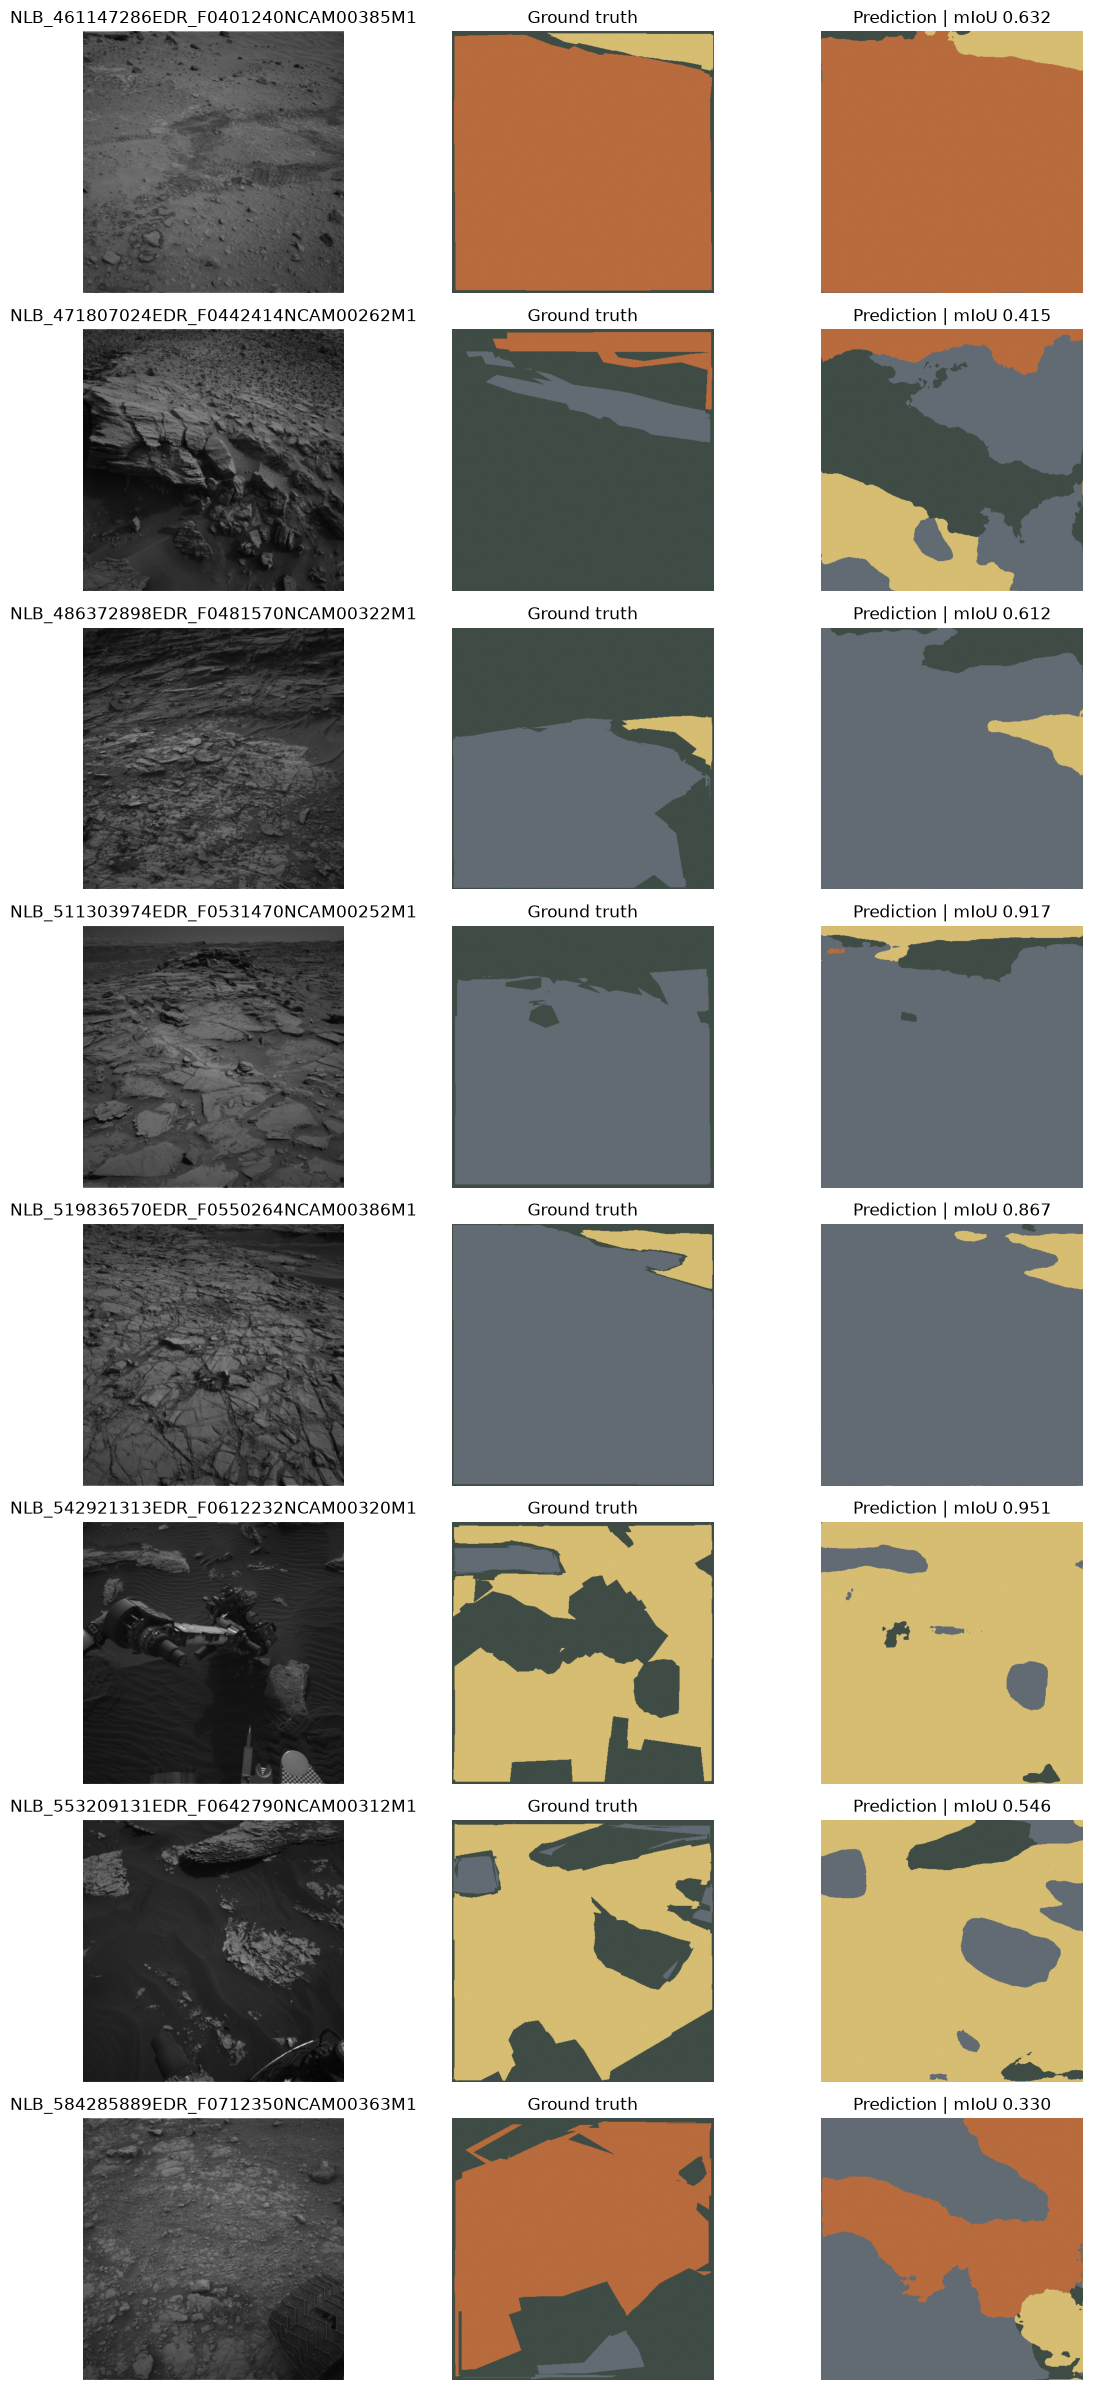

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class_names = ('soil', 'bedrock', 'sand', 'big_rock')
class_colors = ['#b86b3d', '#626b73', '#d6bd72', '#3f4c45']
class_map = ListedColormap(class_colors)

figure, axes = plt.subplots(len(report.predictions), 3, figsize=(12, 3 * len(report.predictions)))
for row, sample in enumerate(report.predictions):
    axes[row, 0].imshow(sample.image)
    axes[row, 0].set_title(sample.source_id)
    axes[row, 1].imshow(sample.target, cmap=class_map, vmin=0, vmax=3)
    axes[row, 1].set_title('Ground truth')
    axes[row, 2].imshow(sample.prediction, cmap=class_map, vmin=0, vmax=3)
    axes[row, 2].set_title(f"Prediction | mIoU {sample.metrics['mean_iou']:.3f}")
    for axis in axes[row]:
        axis.axis('off')
figure.tight_layout()
plt.show()

In [4]:
assert report.checkpoint_epoch == 25
assert len(report.predictions) == 8
assert report.device == 'cpu'
print('PASS: setup, checkpoint, sample integrity, CPU inference, and metric tolerances verified.')

PASS: setup, checkpoint, sample integrity, CPU inference, and metric tolerances verified.
